In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')

import re
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.linear_model import (
    LassoCV,
    Lasso,
)


sys.path.append(os.path.abspath("../"))
from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

# Verification with simulation data
## simulation data
-  repeated cross-section data
- true ATT := 3
- dim(X) := 100
- N = 500

In [2]:
df_rcs =  convert_rcs(
    generate_simdata_ro(true_att=3, _n=2500, _dim=5, base_seed=1, xd_unobserved=False)
)

df_rcs.head()

,x0,x1,x2,x3,x4,D,Y,T
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,0,-2.922698,0
1,-2.301539,1.744812,-0.761207,0.319039,-0.249370,1,-10.909940,1
2,1.462108,-2.060141,-0.322417,-0.384054,1.133769,1,-5.671625,0
3,-1.099891,-0.172428,-0.877858,0.042214,0.582815,0,-8.995497,0
4,-1.100619,1.144724,0.901591,0.502494,0.900856,1,-4.548450,0


In [3]:
y_col = "Y"
d_col = "D"
t_col = "T"
X_cols = [col for col in df_rcs.columns if "x" in col]

## Chang(2022)'s l2k model

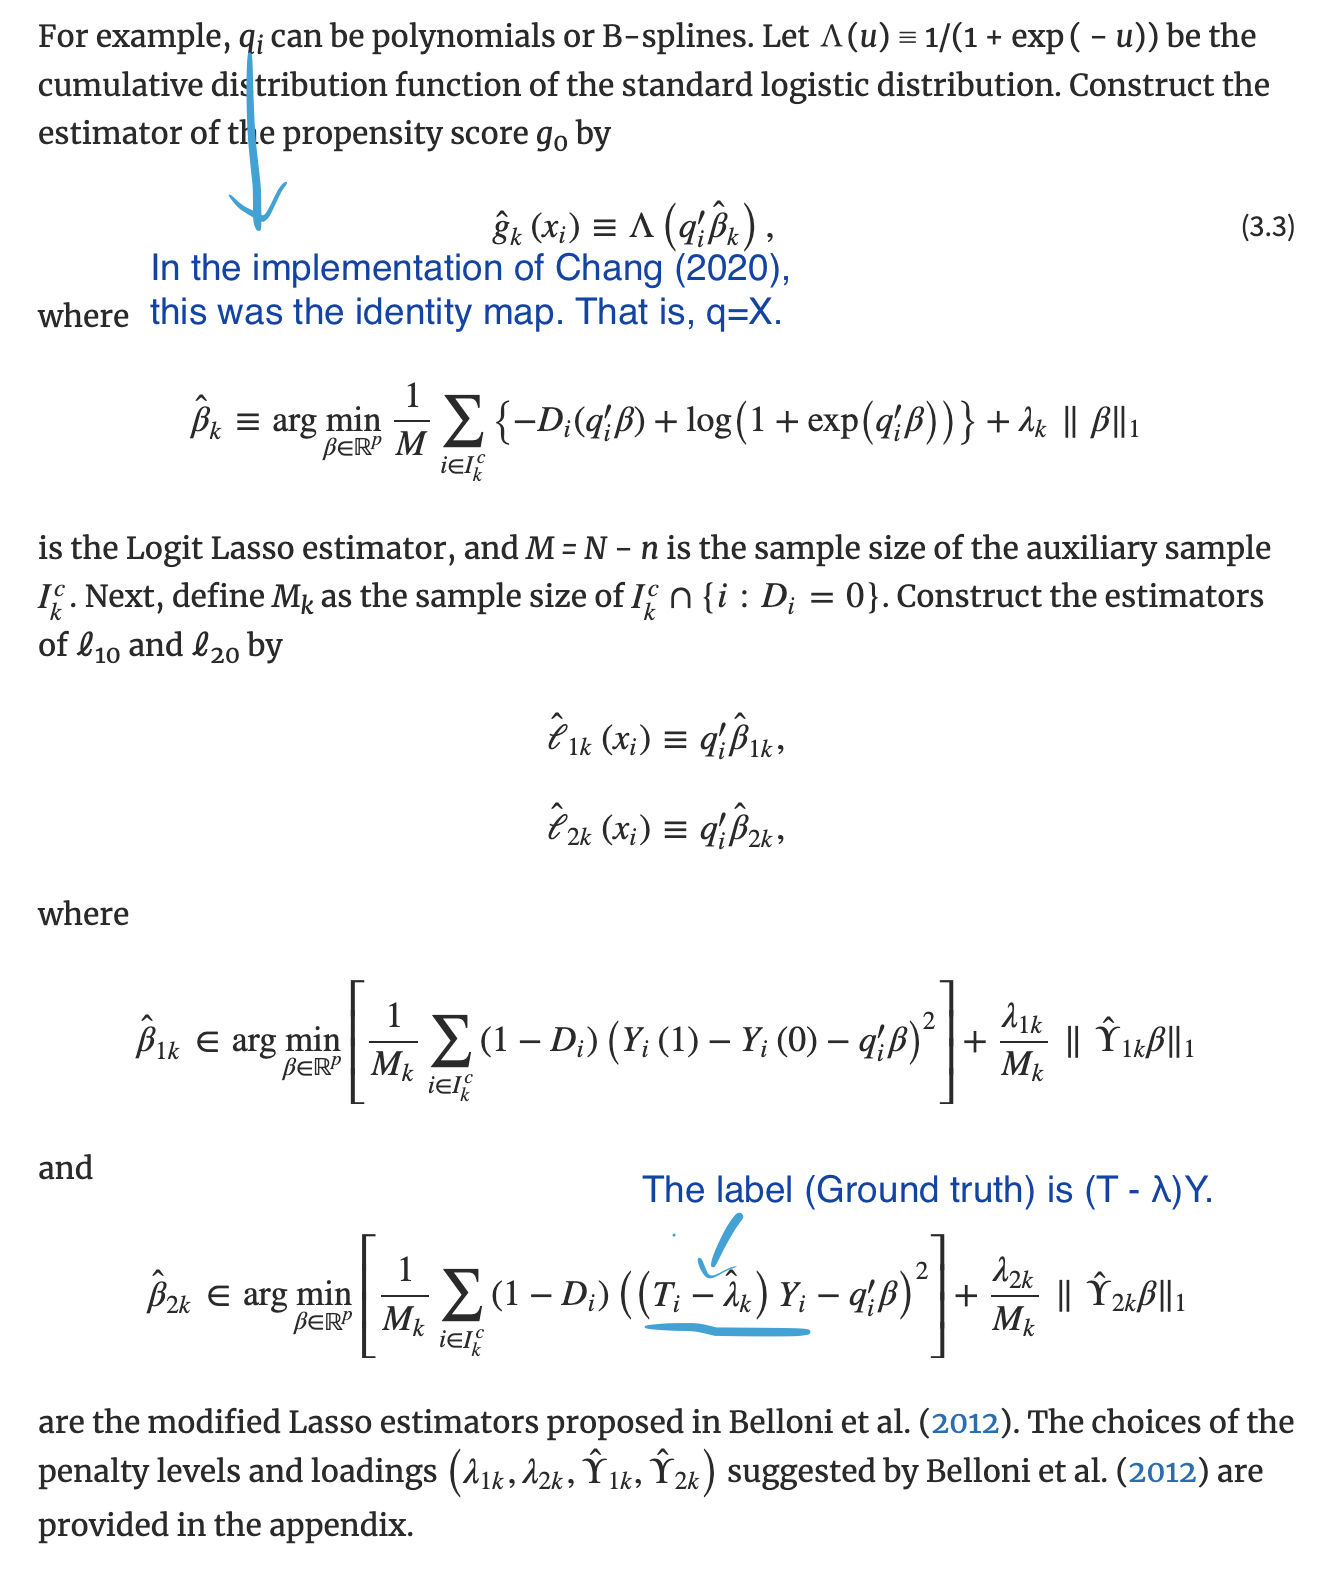

## [X -> l2k label] regression is almost nonsense
### simple example

In [4]:
hat_lambda = df_rcs["T"].mean()

control_df = df_rcs.query("D < 1")
control_df["l2k_y"] = (control_df["T"] - hat_lambda) * control_df["Y"]

In [5]:
control_df[X_cols + ["Y"]].corr()[["Y"]]

,Y
x0,0.364289
x1,0.324934
x2,0.339605
x3,0.286282
x4,0.325304
Y,1.000000


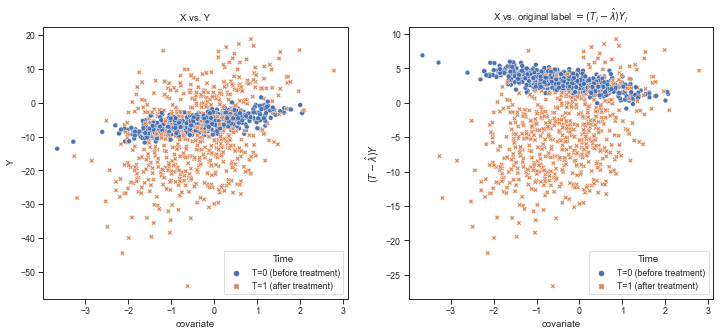

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

sns.scatterplot(
    x="x0",
    y="Y",
    hue="Time",
    style="Time",
    data=control_df.assign(Time = np.where(control_df["T"]>0, "T=1 (after treatment)", "T=0 (before treatment)")),
    ax=axs[0],
    legend="full",
)
axs[0].set_title("X vs. Y")
axs[0].set_xlabel("covariate")


sns.scatterplot(
    x="x0", y="l2k_y", 
    hue="Time",
    style="Time", 
    data=control_df.assign(Time = np.where(control_df["T"]>0, "T=1 (after treatment)", "T=0 (before treatment)")),
    ax=axs[1], 
    legend="full"
)
axs[1].set_title("X vs. original label $= (T_i - \hat{\lambda })Y_i$")
axs[1].set_xlabel("covariate")
axs[1].set_ylabel("$(T - \hat{\lambda })Y$")
fig.savefig("../fig/covariate_to_label.png")
fig.show()

## (1) simple regression result


In [7]:
x_train, x_test, y_train, y_test, l2k_y_train, l2k_y_test = train_test_split(
    control_df[X_cols + [t_col]],
    control_df[y_col],
    control_df["l2k_y"],
    test_size=0.3,
    random_state=0,
)


y_model = LassoCV(cv=5, random_state=0)
l2k_model_withoutT = LassoCV(cv=5, random_state=0)
l2k_model = LassoCV(cv=5, random_state=0)

y_model.fit(x_train, y_train)
l2k_model_withoutT.fit(x_train.iloc[:, :-1], l2k_y_train)
l2k_model.fit(x_train, l2k_y_train)

y_pred = y_model.predict(x_test)
y_mse = mean_squared_error(y_test, y_pred)

l2k_y_pred_withoutT = l2k_model_withoutT.predict(x_test.iloc[:, :-1])
l2k_mse_withoutT = mean_squared_error(l2k_y_test, l2k_y_pred_withoutT)

l2k_y_pred = l2k_model.predict(x_test)
l2k_mse = mean_squared_error(l2k_y_test, l2k_y_pred)

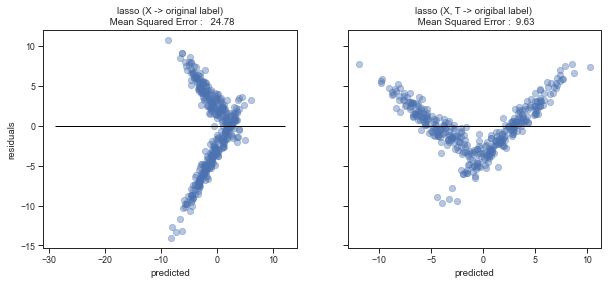

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axs[0].scatter(
    l2k_y_pred_withoutT,
    l2k_y_pred_withoutT - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)
axs[0].set_xlabel("predicted")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")

axs[0].set_title(f"lasso (X -> original label)\n Mean Squared Error :  {l2k_mse_withoutT : .2f}")

axs[1].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)

axs[1].set_xlabel("predicted")
axs[1].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[1].set_title(
    f"lasso (X, T -> origibal label) \n Mean Squared Error : {l2k_mse : .2f}"
)
fig.savefig("../fig/original_l2kmodel_wrong.png")
plt.show()

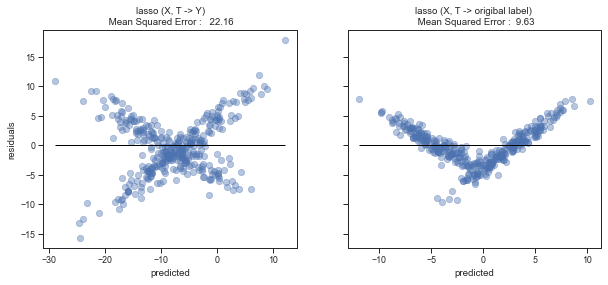

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axs[0].scatter(
    y_pred,
    y_pred - y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression",
)
axs[0].set_xlabel("predicted")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")

axs[0].set_title(f"lasso (X, T -> Y)\n Mean Squared Error :  {y_mse : .2f}")

axs[1].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)

axs[1].set_xlabel("predicted")
axs[1].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[1].set_title(
    f"lasso (X, T -> origibal label) \n Mean Squared Error : {l2k_mse : .2f}"
)
fig.savefig("../fig/why_wrong.png")
plt.show()

## (2) separate model on T

In [10]:
control_df_t1 = control_df.query("T>0")
control_df_t0 = control_df.query("T<1")

x_train_t1, x_test_t1, y_train_t1, y_test_t1 = train_test_split(
    control_df_t1[X_cols + [t_col]],
    control_df_t1[y_col],
    test_size=0.3,
    random_state=0,
)

x_train_t0, x_test_t0, y_train_t0, y_test_t0 = train_test_split(
    control_df_t0[X_cols + [t_col]],
    control_df_t0[y_col],
    test_size=0.3,
    random_state=0,
)


y_model_t1 = LassoCV(cv=5, random_state=0)
y_model_t0 = LassoCV(cv=5, random_state=0)

y_model_t1.fit(x_train_t1, y_train_t1)
y_model_t0.fit(x_train_t0, y_train_t0)

y_pred_t1 = y_model_t1.predict(x_test_t1)
y_mse_t1 = mean_squared_error(y_test_t1, y_pred_t1)

y_pred_t0 = y_model_t0.predict(x_test_t0)
y_mse_t0 = mean_squared_error(y_test_t0, y_pred_t0)

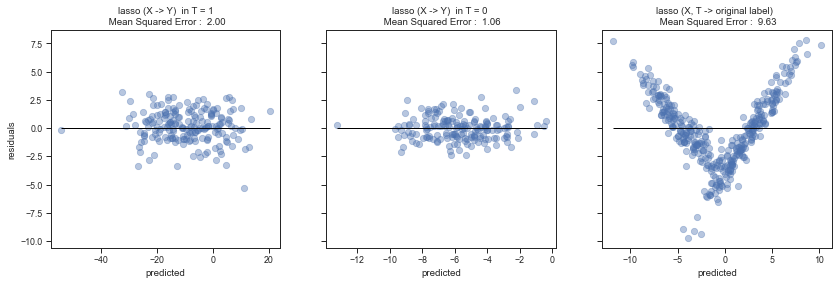

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

axs[0].scatter(
    y_pred_t1,
    y_pred_t1 - y_test_t1,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t1",
)
axs[0].set_xlabel("predicted")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=y_pred_t1.min(), xmax=y_pred_t1.max(), lw=1, color="black")
axs[0].set_title(f"lasso (X -> Y)  in T = 1\n Mean Squared Error : {y_mse_t1 : .2f}")

axs[1].scatter(
    y_pred_t0,
    y_pred_t0 - y_test_t0,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t0",
)
axs[1].set_xlabel("predicted")
axs[1].hlines(y=0, xmin=y_pred_t0.min(), xmax=y_pred_t0.max(), lw=1, color="black")
axs[1].set_title(f"lasso (X -> Y)  in T = 0 \n Mean Squared Error : {y_mse_t0 : .2f}")


axs[2].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)

axs[2].set_xlabel("predicted")
axs[2].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[2].set_title(f"lasso (X, T -> original label)  \n Mean Squared Error : {l2k_mse : .2f}")
fig.savefig("../fig/our_suolution.png")
plt.show()

## (3) nonlinear model

In [12]:
y_model = LGBMRegressor(random_state=0)
l2k_model = LGBMRegressor(random_state=0)
y_model_t1 = LGBMRegressor(random_state=0)
y_model_t0 = LGBMRegressor(random_state=0)

y_model.fit(x_train, y_train)
l2k_model.fit(x_train, l2k_y_train)

y_pred = y_model.predict(x_test)
y_mse = mean_squared_error(y_test, y_pred)

l2k_y_pred = l2k_model.predict(x_test)
l2k_mse = mean_squared_error(l2k_y_test, l2k_y_pred)

y_model_t1.fit(x_train_t1, y_train_t1)
y_model_t0.fit(x_train_t0, y_train_t0)

y_pred_t1 = y_model_t1.predict(x_test_t1)
y_mse_t1 = mean_squared_error(y_test_t1, y_pred_t1)

y_pred_t0 = y_model_t0.predict(x_test_t0)
y_mse_t0 = mean_squared_error(y_test_t0, y_pred_t0)

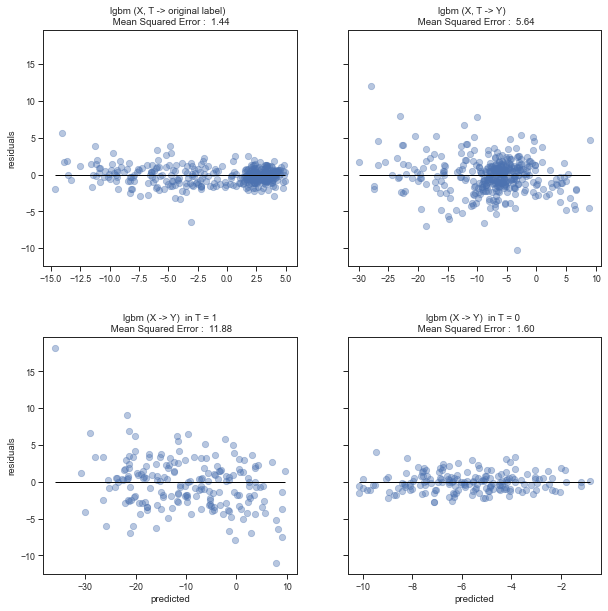

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
fig.subplots_adjust(hspace=0.3)
axs = axs.ravel()
axs[0].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)

# axs[0].set_xlabel("predicted")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[0].set_title(f"lgbm (X, T -> original label)  \n Mean Squared Error : {l2k_mse : .2f}")

axs[1].scatter(
    y_pred,
    y_pred - y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression",
)
#axs[1].set_xlabel("predicted")
axs[1].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")
axs[1].set_title(f"lgbm (X, T -> Y)  \n Mean Squared Error : {y_mse : .2f}")



axs[2].scatter(
    y_pred_t1,
    y_pred_t1 - y_test_t1,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t1",
)
axs[2].set_xlabel("predicted")
axs[2].set_ylabel("residuals")
axs[2].hlines(y=0, xmin=y_pred_t1.min(), xmax=y_pred_t1.max(), lw=1, color="black")
axs[2].set_title(f"lgbm (X -> Y)  in T = 1\n Mean Squared Error : {y_mse_t1 : .2f}")

axs[3].scatter(
    y_pred_t0,
    y_pred_t0 - y_test_t0,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t0",
)
axs[3].set_xlabel("predicted")
axs[3].hlines(y=0, xmin=y_pred_t0.min(), xmax=y_pred_t0.max(), lw=1, color="black")
axs[3].set_title(f"lgbm (X -> Y)  in T = 0 \n Mean Squared Error : {y_mse_t0 : .2f}")


fig.savefig("../fig/lgbm_suolution.png")
plt.show()

In [14]:
print("Done")

Done
